In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dữ liệu
df = pd.read_csv(r"C:\Users\Dell\Documents\GitHub\DS111\Data\Silver\Silver_1.csv")

# 1. Pivot dữ liệu WGI (Indicator) sang các cột riêng biệt
# Quan tâm đặc biệt đến 'pv' (Political Stability) 
df_wgi = df.pivot_table(index=['Country Code', 'Year', 'Partner Name', 'Export (US$ Thousand)', 'has_RCA'], 
                        columns='Indicator', 
                        values='Rank').reset_index()

# Đổi tên cột 
df_wgi.rename(columns={'pv': 'Political_Stability_Rank', 
                       'va': 'Voice_Accountability_Rank',
                       'cc': 'Control_Corruption_Rank',
                       'rl': 'Rule_of_Law_Rank'}, inplace=True)

# 2. Feature Engineering: Tạo biến Log_Export để chuẩn hóa phân phối 
df_wgi['Log_Export'] = np.log1p(df_wgi['Export (US$ Thousand)'])

# Xem trước dữ liệu sau khi xử lý
print("Dữ liệu sau khi pivot và xử lý:")
display(df_wgi.head())

Dữ liệu sau khi pivot và xử lý:


Indicator,Country Code,Year,Partner Name,Export (US$ Thousand),has_RCA,Control_Corruption_Rank,Political_Stability_Rank,Rule_of_Law_Rank,Voice_Accountability_Rank,Log_Export
0,ABW,2004,Aruba,2599745.71,1,85.2,80.6,80.8,73.1,14.770925
1,ABW,2005,Aruba,3141038.78,1,88.3,96.1,78.0,85.6,14.960064
2,ABW,2006,Aruba,3441552.23,1,88.3,96.1,72.7,80.3,15.051433
3,ABW,2007,Aruba,3009284.60,1,88.3,96.6,75.1,78.4,14.917213
4,ABW,2008,Aruba,2899879.76,1,87.4,96.2,76.4,79.3,14.880180


# 1. Phân tích Tương quan (Correlation Analysis)

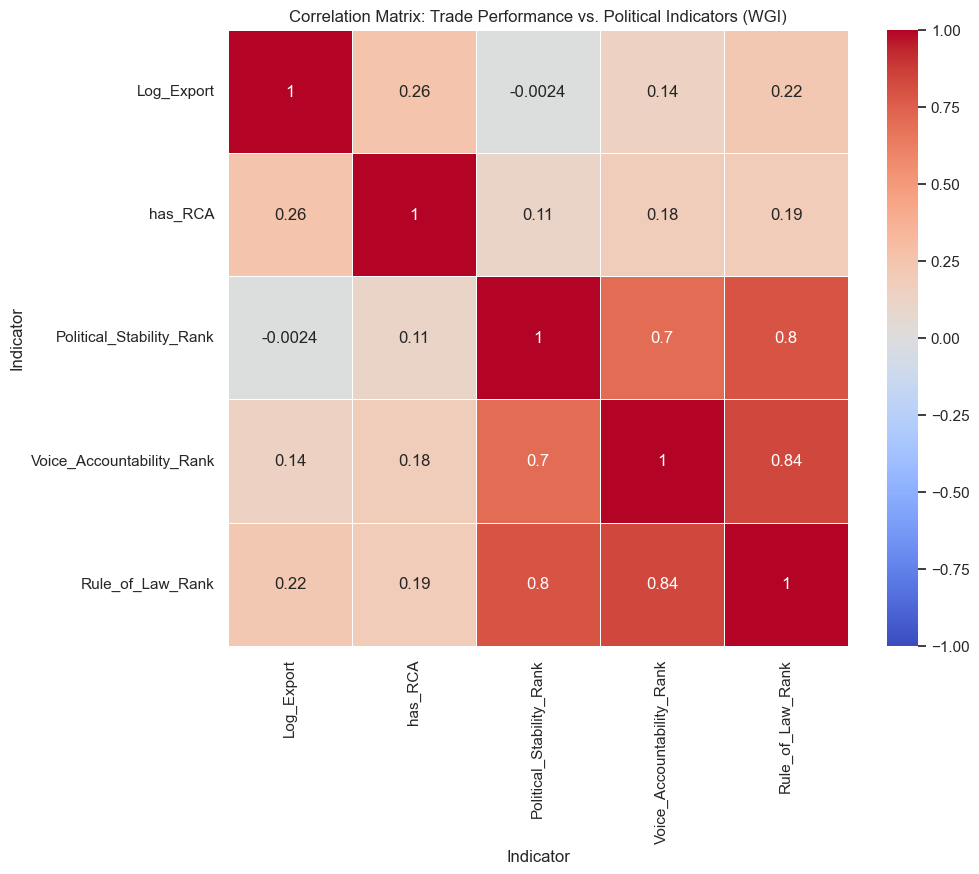

In [2]:
correlation_matrix = df_wgi[['Log_Export', 'has_RCA', 'Political_Stability_Rank', 
                             'Voice_Accountability_Rank', 'Rule_of_Law_Rank']].corr()

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin = -1, vmax = 1, linewidths=0.5)
plt.title('Correlation Matrix: Trade Performance vs. Political Indicators (WGI)')
plt.show()

### 💡Insight: Nghịch lý "Pháp quyền" vs "Ổn định"

Quan sát ma trận tương quan, ta phát hiện một sự phân hóa thú vị giữa các chỉ số quản trị:

* **Rule of Law (RL) vs Log_Export ($r \approx 0.22$):** Có mối tương quan dương đáng kể. Điều này phù hợp với lý thuyết của **Levchenko (2007)**, cho rằng chất lượng thực thi hợp đồng (contract enforcement) đóng vai trò như một nguồn lợi thế so sánh. Các đối tác thương mại quan tâm đến việc "hợp đồng được bảo vệ" hơn là chỉ đơn thuần là "không có bạo loạn".
* **Political Stability (PS) vs Log_Export ($r \approx 0.00$):** Tương quan gần như bằng 0. Điều này cho thấy **Ổn định chính trị không tác động tuyến tính** đến quy mô xuất khẩu.
    * *Lý giải:* Một số quốc gia có thể bất ổn về chính trị nhưng vẫn xuất khẩu lượng lớn tài nguyên thiên nhiên (dầu mỏ, khoáng sản) – nơi quy trình khai thác ít phụ thuộc vào sự tinh vi của thể chế (Institutional Intensity) như lập luận của **Nunn (2007)**.
* **Kết luận:** Để thúc đẩy thương mại, việc cải thiện hệ thống pháp lý (Rule of Law) mang lại hiệu quả trực tiếp rõ rệt hơn so với chỉ tập trung vào ổn định chính trị đơn thuần.

# 2. Trực quan hóa chi tiết - Tác động của Ổn định Chính trị đến RCA

C:\Users\Dell\AppData\Local\Temp\ipykernel_19896\104211582.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='has_RCA', y='Political_Stability_Rank', data=df_wgi, palette="Set2")


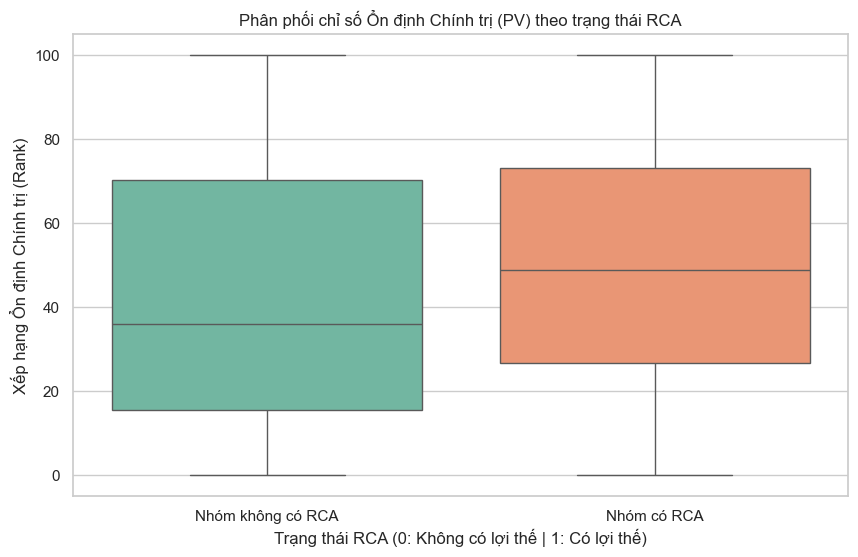

Trung bình Rank Chính trị nhóm KHÔNG RCA: 42.14
Trung bình Rank Chính trị nhóm CÓ RCA: 49.62


In [3]:
# Boxplot so sánh mức độ ổn định chính trị giữa nhóm có RCA và không có RCA
plt.figure(figsize=(10, 6))

# Vẽ Boxplot
sns.boxplot(x='has_RCA', y='Political_Stability_Rank', data=df_wgi, palette="Set2")

plt.title('Phân phối chỉ số Ổn định Chính trị (PV) theo trạng thái RCA')
plt.xlabel('Trạng thái RCA (0: Không có lợi thế | 1: Có lợi thế)')
plt.ylabel('Xếp hạng Ổn định Chính trị (Rank)')
plt.xticks([0, 1], ['Nhóm không có RCA', 'Nhóm có RCA'])
plt.show()

# Kiểm định nhanh trung bình
mean_no_rca = df_wgi[df_wgi['has_RCA']==0]['Political_Stability_Rank'].mean()
mean_yes_rca = df_wgi[df_wgi['has_RCA']==1]['Political_Stability_Rank'].mean()
print(f"Trung bình Rank Chính trị nhóm KHÔNG RCA: {mean_no_rca:.2f}")
print(f"Trung bình Rank Chính trị nhóm CÓ RCA: {mean_yes_rca:.2f}")

### 💡 Insight: "Phần thưởng" của sự ổn định (Stability Premium)

Biểu đồ Boxplot làm sáng tỏ vai trò của Ổn định chính trị đối với **chất lượng** thương mại (RCA) thay vì số lượng:

* **Sự chênh lệch rõ rệt:** Nhóm quốc gia đạt được Lợi thế so sánh (RCA = 1) có chỉ số Ổn định chính trị trung bình (**~49.6**) cao hơn đáng kể so với nhóm không có lợi thế (**~42.1**). Khoảng cách này là gần **7.5 bậc xếp hạng**.
* **Ý nghĩa:** Dữ liệu ủng hộ giả thuyết rằng sự ổn định là "điều kiện cần" để tham gia vào các chuỗi cung ứng giá trị cao. Các quốc gia bất ổn thường bị "mắc kẹt" ở nhóm hàng hóa không có RCA hoặc chỉ có RCA ở dạng tài nguyên thô.
* **Đối chiếu:** Kết quả này phù hợp với mô hình của **Anderson & Marcouiller (2002)**, khi sự bất an ninh (insecurity) hoạt động như một loại thuế ẩn làm xói mòn lợi thế cạnh tranh của quốc gia.

# 3. Scatter Plot với Đường Hồi quy (Trendline)

- Xem xét mối quan hệ tuyến tính giữa sự ổn định và quy mô xuất khẩu

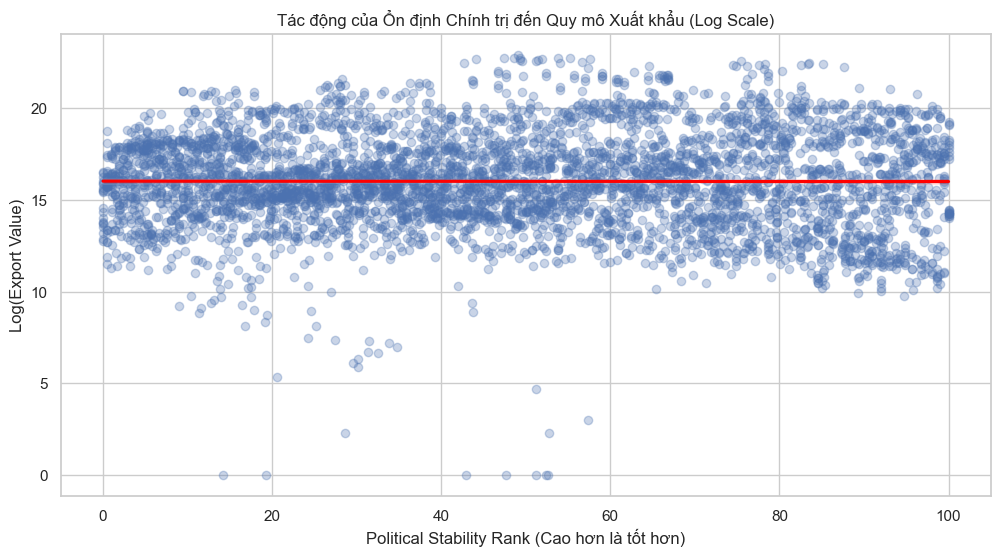

In [4]:
plt.figure(figsize=(12, 6))
sns.regplot(x='Political_Stability_Rank', y='Log_Export', data=df_wgi, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Tác động của Ổn định Chính trị đến Quy mô Xuất khẩu (Log Scale)')
plt.xlabel('Political Stability Rank (Cao hơn là tốt hơn)')
plt.ylabel('Log(Export Value)')
plt.show()

### 💡 Insight: Tại sao đường hồi quy lại "phẳng"?

Biểu đồ phân tán cho thấy đường xu hướng (Trendline) gần như nằm ngang, phản ánh mối tương quan rất thấp giữa `Political Stability` và `Log_Export`.

**Giải thích:**
1.  **Yếu tố quy mô (Scale Effect):** Một số quốc gia rất ổn định (Rank cao) nhưng là đảo quốc nhỏ (Small Island States) nên tổng kim ngạch xuất khẩu thấp. Ngược lại, các cường quốc mới nổi có thể xuất khẩu cực lớn dù chỉ số ổn định chỉ ở mức trung bình.
2.  **Bẫy thu nhập:** Ổn định chính trị giúp quốc gia **thu hút FDI** và **cải thiện RCA** (như thấy ở Boxplot), nhưng không đảm bảo tăng trưởng "thần tốc" về con số tuyệt đối nếu thiếu các yếu tố đầu vào khác (lao động, vốn).
3.  **Hàm ý cho mô hình:** Trong mô hình dự báo, biến `Political Stability` nên được xem xét dưới dạng **phi tuyến** (non-linear) hoặc là biến tương tác (interaction term) với Thuế quan, thay vì kỳ vọng nó tác động độc lập đến tổng kim ngạch.